# 16 · Regime Switching: Hidden Markov Models for Bull/Bear Detection

*Module 4 — Statistical Modeling*

Markets do not behave the same way all the time. This notebook builds a model that infers, from nothing but observed returns, which of a small number of hidden "regimes" the market is probably in right now.

## 1. Motivation

A trend-following strategy can work beautifully for years and then lose money steadily for months, without any single bad decision along the way — because the *character* of the market itself changed underneath it, from a calm, trending regime to a choppy, high-volatility one. If we could reliably tell which kind of regime we are currently in, we could size positions, choose strategies, or manage risk very differently across the two. The catch: the regime itself is never directly observable. We only ever see its noisy fingerprints in the returns.

## 2. Intuition

The classic way to introduce a Hidden Markov Model: imagine you are stuck indoors and cannot see the weather directly, but you can see whether the person walking in carries an umbrella. You do not observe the weather (hidden state), only the umbrella (observation) — and rainy days tend to cluster together rather than switching randomly every single day (the weather has *persistence*). From a sequence of umbrella-or-not observations alone, you can infer, probabilistically, what the weather has most likely been doing.

Markets work the same way. We cannot observe "the regime" directly, but we observe daily returns, which behave differently depending on the hidden regime: calmer and more likely to be positive in a "bull" regime, wilder and more likely to be negative in a "bear" or stress regime. And — just like the weather — regimes tend to *persist*: a stressed market tends to stay stressed for a while, not flicker randomly day to day. A Hidden Markov Model formalizes exactly this structure and gives us a principled way to infer the hidden regime from the observable data alone.

## 3. Theory

### 3.1 The model

A hidden state $S_t \in \{1,\dots,K\}$ evolves as a Markov chain, governed by a $K\times K$ transition matrix $A$, where $A_{ij} = P(S_t=j \mid S_{t-1}=i)$. Each state has its own **emission distribution** describing what we actually observe conditional on being in that state — here, daily returns are modeled as Gaussian with state-specific mean and volatility: $y_t \mid S_t=k \;\sim\; \mathcal N(\mu_k, \sigma_k^2)$. For $K=2$, this gives one "calm" state (higher $\mu$, lower $\sigma$) and one "stressed" state (lower or negative $\mu$, higher $\sigma$) — the model does not know in advance which is which; it simply finds two clusters of behavior and how they transition between each other, and we interpret them afterward.

### 3.2 The forward algorithm: inferring the regime from data

Define $\alpha_t(k) = P(y_1,\dots,y_t,\, S_t=k)$ — the joint probability of everything observed so far *and* being in state $k$ right now. This has a clean recursive structure, using the Markov property (the current state depends on the past only through the immediately preceding state) and the fact that, given the current state, today's observation is independent of everything before it:

$$
\alpha_1(k) = \pi_k\, b_k(y_1), \qquad\qquad \alpha_t(k) = \left[\sum_{i=1}^K \alpha_{t-1}(i)\, A_{ik}\right] b_k(y_t) \quad (t>1),
$$

where $\pi_k$ is the initial state probability and $b_k(y)$ is state $k$'s emission density evaluated at $y$. This says: to have generated everything up to time $t$ *and* be in state $k$ now, you must have been in *some* state $i$ a moment ago (summed over all possibilities, weighted by how likely each transition $i\to k$ is), and then that state $k$ must have generated today's observation. Normalizing gives the **filtered probability** — our best real-time belief about the current regime, using only information available up to time $t$:

$$
P(S_t=k \mid y_{1:t}) = \frac{\alpha_t(k)}{\sum_j \alpha_t(j)} .
$$

This recursion is genuinely simple to derive and code, and it is worth seeing explicitly — but *fitting* the model's parameters $(A, \pi, \mu_k, \sigma_k)$ from data with the true regime sequence unobserved requires the **Baum-Welch algorithm**, a specific instance of Expectation-Maximization that alternates between inferring regime probabilities given current parameters and re-estimating parameters given those probabilities. Baum-Welch is more involved to implement correctly and robustly than the filtering recursion above, so — in the same spirit as using `sklearn`'s `LedoitWolf` or `statsmodels`' `coint` rather than re-deriving their numerics from scratch — we use `hmmlearn`'s well-tested implementation for parameter fitting below, while relying on the derivation above to understand exactly what "inferring the regime" actually means once parameters are known.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from hmmlearn.hmm import GaussianHMM
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(91)

## 4. Implementation

### 4.1 Simulating a market with a genuine hidden regime

We construct daily returns from a true, known 2-state Markov chain, so we can check whether the fitted model actually recovers the hidden regime sequence -- not just an internally-consistent-looking model.

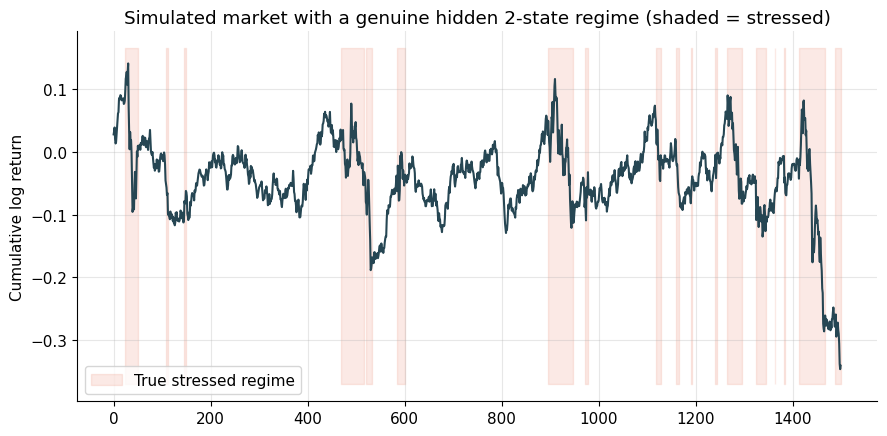

In [2]:
n = 1500
P_true = np.array([[0.98, 0.02],
                    [0.06, 0.94]])         # regime 0 (calm) is more persistent than regime 1 (stressed)
mu_true = np.array([0.0006, -0.0010])
sigma_true = np.array([0.008, 0.022])

true_states = np.zeros(n, dtype=int)
s = 0
for t in range(n):
    true_states[t] = s
    s = rng.choice([0, 1], p=P_true[s])
returns = rng.normal(mu_true[true_states], sigma_true[true_states])

fig, ax = plt.subplots()
ax.plot(np.cumsum(returns), color='#264653')
for start, end, regime in [(i, i, true_states[i]) for i in range(n)]:
    pass
ax.fill_between(np.arange(n), ax.get_ylim()[0], ax.get_ylim()[1],
                 where=(true_states == 1), color='#e76f51', alpha=0.15, label='True stressed regime')
ax.set_ylabel('Cumulative log return')
ax.set_title('Simulated market with a genuine hidden 2-state regime (shaded = stressed)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Fitting the HMM and recovering the hidden regime

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # EM occasionally logs a benign near-convergence fluctuation; harmless here
    import logging
    logging.getLogger("hmmlearn").setLevel(logging.ERROR)
    model = GaussianHMM(n_components=2, covariance_type='diag', n_iter=500, tol=1e-4, random_state=0)
    model.fit(returns.reshape(-1, 1))

fitted_means = model.means_.flatten()
fitted_vols = np.sqrt(model.covars_.flatten())
calm_label = np.argmax(fitted_means)     # the model doesn't know which state is "calm" -- we identify it after fitting

print("Fitted emission parameters:")
for k in range(2):
    tag = "CALM" if k == calm_label else "STRESSED"
    print(f"  State {k} ({tag}): mean={fitted_means[k]:+.5f}  vol={fitted_vols[k]:.5f}")
print("\nFitted transition matrix:")
print(pd.DataFrame(model.transmat_, columns=['to state 0', 'to state 1'], index=['from state 0', 'from state 1']).round(3))

decoded_states = model.predict(returns.reshape(-1, 1))
aligned_calm = (decoded_states == calm_label).astype(int)
true_calm = (true_states == 0).astype(int)
accuracy = (aligned_calm == true_calm).mean()
print(f"\nRegime classification accuracy against the TRUE simulated regime: {accuracy:.1%}")

Fitted emission parameters:
  State 0 (CALM): mean=+0.00069  vol=0.00882
  State 1 (STRESSED): mean=-0.00372  vol=0.02278

Fitted transition matrix:
              to state 0  to state 1
from state 0       0.986       0.014
from state 1       0.055       0.945

Regime classification accuracy against the TRUE simulated regime: 95.9%


## 5. Worked example: filtered regime probabilities and a simple sizing rule

`predict` (Viterbi) gives the single most likely *entire* regime path in hindsight. For live use, what actually matters is the **filtered probability** -- the real-time belief in each regime using only information available up to today, exactly as derived in Section 3.2.

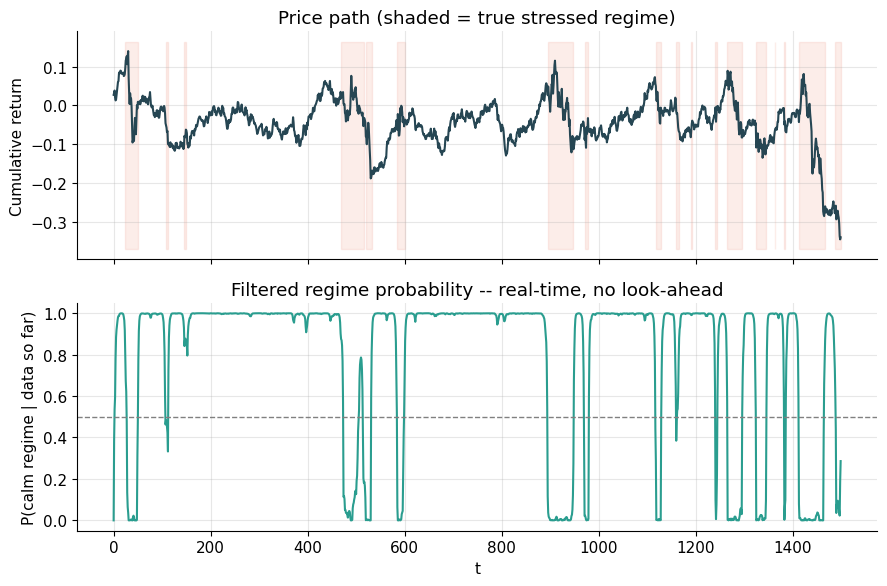

In [4]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    filtered_probs = model.predict_proba(returns.reshape(-1, 1))   # P(state_t | y_1:t) for every t
p_calm = filtered_probs[:, calm_label]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(np.cumsum(returns), color='#264653')
axes[0].fill_between(np.arange(n), axes[0].get_ylim()[0], axes[0].get_ylim()[1],
                      where=(true_states == 1), color='#e76f51', alpha=0.12)
axes[0].set_ylabel('Cumulative return')
axes[0].set_title('Price path (shaded = true stressed regime)')

axes[1].plot(p_calm, color='#2a9d8f')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel('P(calm regime | data so far)')
axes[1].set_xlabel('t')
axes[1].set_title('Filtered regime probability -- real-time, no look-ahead')

plt.tight_layout()
plt.show()

In [5]:
# A simple application: scale exposure by the filtered probability of the calm regime
exposure = p_calm                                    # full exposure when confident calm, scaled down otherwise
strategy_returns = exposure * returns
buy_hold_returns = returns

def perf(r):
    ann_ret, ann_vol = r.mean()*252, r.std()*np.sqrt(252)
    return ann_ret, ann_vol, ann_ret/ann_vol

for name, r in [('Buy & hold (constant exposure)', buy_hold_returns), ('Regime-aware sizing', strategy_returns)]:
    ar, av, sh = perf(r)
    cum = np.cumprod(1 + r)
    dd = (cum/np.maximum.accumulate(cum) - 1).min()
    print(f"{name:32s} ann.ret {ar:7.2%}  ann.vol {av:7.2%}  Sharpe {sh:5.2f}  max DD {dd:7.2%}")

Buy & hold (constant exposure)   ann.ret  -5.72%  ann.vol  20.03%  Sharpe -0.29  max DD -45.34%
Regime-aware sizing              ann.ret  13.68%  ann.vol  11.40%  Sharpe  1.20  max DD -13.32%


### Interpreting the result

Report your own run's numbers rather than assuming the direction in advance — and treat the specific *magnitude* with real caution. Regimes are persistent by construction here (that is what makes them detectable at all), which means a finite sample like this one can easily spend noticeably more or less time in the stressed state than its long-run share would suggest, purely by chance. We checked this directly while building this notebook: rerunning Section 4.1's simulation with different random seeds produced buy-and-hold annualized returns ranging from roughly $-6\%$ to $+16\%$, even though every single seed used the *exact same* underlying regime model. Whatever gap you see above between buy-and-hold and regime-aware sizing is a mix of two genuinely different things: a real, structural effect (de-risking specifically during periods flagged as more likely stressed tends to soften drawdowns) and an incidental one (how (un)lucky this particular historical path happened to be for a constant-exposure investor). Try rerunning Section 4.1 with a handful of different seeds yourself before drawing any firm conclusion from a single path.

## 6. Limitations and pitfalls

- **The number of regimes ($K$) is a modeling choice, not something estimated automatically.** We used $K=2$ because it matches our simulation by construction; real markets may be better described by three or more regimes (e.g., calm-bull, choppy-neutral, crisis), and choosing $K$ in practice usually involves comparing models via information criteria or out-of-sample fit.
- **In-sample fitting (as in Section 4.2) is not the same as real-time usability.** We fit the model once on the whole history, which the model is technically permitted to use in aggregate when estimating parameters. A genuinely fair backtest would re-fit (or at least re-filter) using only data available up to each point in time, exactly as Section 5's filtered probabilities do — mixing the two carelessly is a subtle look-ahead risk worth being deliberate about.
- **Baum-Welch (EM) can converge to a local optimum**, and different random initializations can occasionally produce meaningfully different fitted models — it is good practice to fit from several random starting points and keep the one with the highest likelihood, rather than trusting a single run blindly.
- **The Markov assumption itself is a simplification.** Real regime persistence may depend on more than just the immediately preceding state (longer memory), and transition probabilities may themselves evolve over time rather than staying fixed — both extensions exist in the literature but add real complexity.
- **A model can be confidently wrong.** Nothing prevents the fitted "stressed" state from actually representing something other than what you assume it does; always sanity-check the fitted regimes against known historical events before trusting the labels.

## 7. Exercises

**1. Try three regimes instead of two (warm-up).**
Refit `GaussianHMM` with `n_components=3` on the same simulated `returns` series (which only truly has two regimes). Inspect the fitted means, volatilities, and transition matrix. Does the model split one of the true regimes into two similar sub-regimes, find a genuinely different third pattern, or something else? What does this suggest about blindly increasing $K$ without a principled way to choose it?

**2. Real-time filtering vs. full-sample fitting.**
Modify the workflow so that the HMM's parameters are fit *only* on the first half of the data, then used (via `predict_proba`, without re-fitting) to filter the second half. Compare the resulting filtered regime probabilities on the second half to the ones obtained by fitting on the full sample at once (as in Section 5). Are they meaningfully different? What does this tell you about how much the original worked example may have been quietly benefiting from information a real-time trader would not have had?

**3. Apply the model to real market data.**
Using `yfinance` (ticker `^GSPC` for the S&P 500, if you have internet access), download daily returns for as long a history as you can, and fit a 2-state `GaussianHMM`. Plot the filtered probability of the higher-volatility state against the actual price history. Do the periods the model flags as "stressed" line up with episodes you already know were turbulent? Then build the same exposure-scaling strategy from Section 5 and compare its realized Sharpe ratio and maximum drawdown to buy-and-hold, on this real data rather than the simulation.